### Reproduction of Thornhill's Results :



| Topic|Link|
|-|-|
|Wroking with time|https://docs.python.org/3/library/datetime.html|
|IGE interanet|https://ige-intranet.osug.fr/|
|For Coding time|to google: jupyter "magic commands" eg %time and %%time|
|models data|Short wave (outgoing and outcoming), Longwave |
|ESGF|https://aims2.llnl.gov/cart/items|
|Article(Thornhill)|https://acp.copernicus.org/articles/21/1105/2021/acp-21-1105-2021.pdf|


### Understanding the Scientific Context:
The article investigates climate feedbacks in CMIP6 Earth system models, with a focus on natural emissions(feedbacks) like DMS and their radiative effects. The piClim-control experiment represents pre-industrial (1850) conditions, while piClim-2xDMS doubles oceanic DMS emissions relative to the control. The ERF quantifies the change in the top-of-atmosphere (TOA) radiative balance due to this perturbation, calculated using fixed sea surface temperatures (SSTs) over a 30-year period.

The data files provided contain:

* rlut: Outgoing longwave radiation at TOA (W m⁻²)
* rsdt: Incoming shortwave radiation at TOA (W m⁻²)
* rsut: Outgoing shortwave radiation at TOA (W m⁻²)

These variables are available for both experiments in the UKESM1-0-LL model, with filenames indicating a time span from January 1850 to December 1894
**(45 years)** . However, the article specifies a 30-year mean for ERF calculations (Section 2.2), so we’ll need to confirm the time dimension in the data and adjust accordingly.


### Defining the ERF Calculation:
The ERF is the difference in the net TOA radiative flux between the perturbed (piClim-2xDMS) and control (piClim-control) experiments. The net flux N at TOA is defined as: 

**N** = Incoming short-outgoing long - outgoing short   =    RSDT - RLUT - RSUT

**ERF = N<sub>2xDMS</sub> − N<sub>control</sub>**   This should be done over 30 years 
* Since the experiments use fixed SSTs, this difference directly yields the ERF, including rapid adjustments, without the full climate response. SST is a global mean temperature.
 ### Weighted Mean Formula

+ The area-weighted mean is calculated as:

$$
\text{Mean} = \frac{\sum_{i=1}^{n} (ERF_i \cdot w_i)}{\sum_{i=1}^{n} w_i}
$$

Where:
- $ERF_i$ = Effective Radiative Forcing at grid point $i$
- $w_i$ = weight at grid point $i$ (typically $\cos(\phi_i)$ for latitude $\phi_i$)
- $n$ = total number of grid points

* specific 30-year subset (e.g., 1850–1879), modify the code with a time slice, e.g., rsut_2xDMS = rsut_2xDMS.isel(time=slice(0, 360)) (360 months = 30 years).

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
from watermark import watermark

In [2]:
watermark(iversions=True, globals_=globals())

'pandas    : 2.2.3\nmatplotlib: 3.10.0\nnumpy     : 2.0.2\nwatermark : 2.5.0\nxarray    : 2025.1.1\ncartopy   : 0.24.0\n'

In [3]:
# Load data
#UKESM
rlut_2xDMS = xr.open_dataset('rlut_Amon_UKESM1-0-LL_piClim-2xDMS_r1i1p1f4_gn_185001-189412.nc')['rlut']
rsut_2xDMS = xr.open_dataset('rsut_Amon_UKESM1-0-LL_piClim-2xDMS_r1i1p1f4_gn_185001-189412.nc')['rsut']
rsdt_2xDMS = xr.open_dataset('rsdt_Amon_UKESM1-0-LL_piClim-2xDMS_r1i1p1f4_gn_185001-189412.nc')['rsdt']

rlut_control = xr.open_dataset('rlut_Amon_UKESM1-0-LL_piClim-control_r1i1p1f4_gn_185001-189412.nc')['rlut']
rsut_control = xr.open_dataset('rsut_Amon_UKESM1-0-LL_piClim-control_r1i1p1f4_gn_185001-189412.nc')['rsut']
rsdt_control = xr.open_dataset('rsdt_Amon_UKESM1-0-LL_piClim-control_r1i1p1f4_gn_185001-189412.nc')['rsdt']

# NORESMLM 1
rlut1_2xDMS = xr.open_dataset('rlut_Amon_NorESM2-LM_piClim-2xDMS_r1i1p1f1_gn_000101-001012.nc')['rlut']
rsut1_2xDMS = xr.open_dataset('rsut_Amon_NorESM2-LM_piClim-2xDMS_r1i1p1f1_gn_000101-001012.nc')['rsut']
rsdt1_2xDMS = xr.open_dataset('rsdt_Amon_NorESM2-LM_piClim-2xDMS_r1i1p1f1_gn_000101-001012.nc')['rsdt']

rlut1_control = xr.open_dataset('rlut_Amon_NorESM2-LM_piClim-control_r1i1p1f1_gn_000101-001012.nc')['rlut']
rsut1_control = xr.open_dataset('rsut_Amon_NorESM2-LM_piClim-control_r1i1p1f1_gn_000101-001012.nc')['rsut']
rsdt1_control = xr.open_dataset('rsdt_Amon_NorESM2-LM_piClim-control_r1i1p1f1_gn_000101-001012.nc')['rsdt']

#GISS E2 -1 -G
rlut2_2xDMS = xr.open_dataset('rlut_Amon_GISS-E2-1-G_piClim-2xDMS_r1i1p3f1_gn_195001-199012.nc')['rlut']
rsut2_2xDMS = xr.open_dataset('rsut_Amon_GISS-E2-1-G_piClim-2xDMS_r1i1p3f1_gn_195001-199012.nc')['rsut']
rsdt2_2xDMS = xr.open_dataset('rsdt_Amon_GISS-E2-1-G_piClim-2xDMS_r1i1p3f1_gn_195001-199012.nc')['rsdt']

rlut2_control = xr.open_dataset('rlut_Amon_GISS-E2-1-G_piClim-control_r1i1p3f1_gn_195001-199012.nc')['rlut']
rsut2_control = xr.open_dataset('rsut_Amon_GISS-E2-1-G_piClim-control_r1i1p3f1_gn_195001-199012.nc')['rsut']
rsdt2_control = xr.open_dataset('rsdt_Amon_GISS-E2-1-G_piClim-control_r1i1p3f1_gn_195001-199012.nc')['rsdt']

In [4]:
rsdt_control.head()   # dimension of all the file is W/M^2

<xarray.DataArray 'rsdt' (time: 5, lat: 5, lon: 5)> Size: 500B
[125 values with dtype=float32]
Coordinates:
  * time     (time) object 40B 1850-01-16 00:00:00 ... 1850-05-16 00:00:00
  * lat      (lat) float64 40B -89.38 -88.12 -86.88 -85.62 -84.38
  * lon      (lon) float64 40B 0.9375 2.812 4.688 6.562 8.438
Attributes:
    standard_name:  toa_incoming_shortwave_flux
    long_name:      TOA Incident Shortwave Radiation
    comment:        Shortwave radiation incident at the top of the atmosphere
    units:          W m-2
    original_name:  mo: (stash: m01s01i207, lbproc: 128)
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [5]:
# Check time dimension
print("Time steps in 2xDMS:", rlut_2xDMS.time.size)
print("Time steps in control:", rlut_control.time.size)

Time steps in 2xDMS: 540
Time steps in control: 540


In [6]:
# Verify the Time Period
print("First time step:", rlut_2xDMS.time[0].values)
print("Last time step:", rlut_2xDMS.time[-1].values)

First time step: 1850-01-16 00:00:00
Last time step: 1894-12-16 00:00:00


In [7]:
# Subset to the Last 30 Years
# Subset to last 30 years (360 months)
rlut_2xDMS_last30 = rlut_2xDMS.isel(time=slice(-360, None))
rsut_2xDMS_last30 = rsut_2xDMS.isel(time=slice(-360, None))
rsdt_2xDMS_last30 = rsdt_2xDMS.isel(time=slice(-360, None))
rlut_control_last30 = rlut_control.isel(time=slice(-360, None))
rsut_control_last30 = rsut_control.isel(time=slice(-360, None))
rsdt_control_last30 = rsdt_control.isel(time=slice(-360, None))

# Verify the subset time range
print("First time step of last 30 years:", rlut_2xDMS_last30.time[0].values)
print("Last time step of last 30 years:", rlut_2xDMS_last30.time[-1].values)

First time step of last 30 years: 1865-01-16 00:00:00
Last time step of last 30 years: 1894-12-16 00:00:00


In [8]:
# Net flux for 2xDMS

N_2xDMS_last30 = rsdt_2xDMS_last30 - rsut_2xDMS_last30 - rlut_2xDMS_last30

# Net flux for control
N_control_last30 = rsdt_control_last30 - rsut_control_last30 - rlut_control_last30

In [9]:
#Calculate Time Mean
#Compute the time mean of the net flux over the 30-year period:
#collapsing 30 years of data into a single mean value 
#at each spatial point (lat/lon) or other remaining dimensions.

N_2xDMS_mean_last30 = N_2xDMS_last30.mean(dim='time')
N_control_mean_last30 = N_control_last30.mean(dim='time')

In [10]:
# Compute Effective Radiative Forcing (ERF)
ERF_last30 = N_2xDMS_mean_last30 - N_control_mean_last30

In [11]:
weights = np.cos(np.deg2rad(ERF_last30.lat))
# Normalize weights so they sum to 1

global_mean_ERF_last30 = ERF_last30.weighted(weights).mean(dim=['lat', 'lon'])
print(f"Global mean ERF UKESM(last 30 years): {global_mean_ERF_last30.values:.3f} W m⁻²")

Global mean ERF UKESM(last 30 years): -1.192 W m⁻²


#### Second Model : NorESM2

In [12]:
rlut1_2xDMS_last30 = rlut1_2xDMS.isel(time=slice(-360, None))
rsut1_2xDMS_last30 = rsut1_2xDMS.isel(time=slice(-360, None))
rsdt1_2xDMS_last30 = rsdt1_2xDMS.isel(time=slice(-360, None))
rlut1_control_last30 = rlut1_control.isel(time=slice(-360, None))
rsut1_control_last30 = rsut1_control.isel(time=slice(-360, None))
rsdt1_control_last30 = rsdt1_control.isel(time=slice(-360, None))


N1_2xDMS_last30 = rsdt1_2xDMS_last30 - rsut1_2xDMS_last30 - rlut1_2xDMS_last30
N1_control_last30 = rsdt1_control_last30 - rsut1_control_last30 - rlut1_control_last30

N1_2xDMS_mean_last30 = N1_2xDMS_last30.mean(dim='time')
N1_control_mean_last30 = N1_control_last30.mean(dim='time')

ERF1_last30 = N1_2xDMS_mean_last30 - N1_control_mean_last30


weights1 = np.cos(np.deg2rad(ERF1_last30.lat))
# Normalize weights so they sum to 1

global_mean_ERF1_last30 = ERF1_last30.weighted(weights1).mean(dim=['lat', 'lon'])
print(f"Global mean ERF NorESM2(last 30 years): {global_mean_ERF1_last30.values:.3f} W m⁻²")

Global mean ERF NorESM2(last 30 years): -1.240 W m⁻²


### Third  Model: GISS

In [13]:

rlut2_2xDMS_last30 = rlut2_2xDMS.isel(time=slice(-360, None))
rsut2_2xDMS_last30 = rsut2_2xDMS.isel(time=slice(-360, None))
rsdt2_2xDMS_last30 = rsdt2_2xDMS.isel(time=slice(-360, None))
rlut2_control_last30 = rlut2_control.isel(time=slice(-360, None))
rsut2_control_last30 = rsut2_control.isel(time=slice(-360, None))
rsdt2_control_last30 = rsdt2_control.isel(time=slice(-360, None))


N2_2xDMS_last30 = rsdt2_2xDMS_last30 - rsut2_2xDMS_last30 - rlut2_2xDMS_last30
N2_control_last30 = rsdt2_control_last30 - rsut2_control_last30 - rlut2_control_last30

N2_2xDMS_mean_last30 = N2_2xDMS_last30.mean(dim='time')
N2_control_mean_last30 = N2_control_last30.mean(dim='time')

ERF2_last30 = N2_2xDMS_mean_last30 - N2_control_mean_last30


weights2 = np.cos(np.deg2rad(ERF2_last30.lat))
# Normalize weights so they sum to 1

global_mean_ERF2_last30 = ERF2_last30.weighted(weights2).mean(dim=['lat', 'lon'])
print(f"Global mean ERF GISS(last 30 years): {global_mean_ERF2_last30.values:.3f} W m⁻²")

Global mean ERF GISS(last 30 years): -0.610 W m⁻²


### Arctic Mean ERF Calculation
+ Added a parameter arctic_lat_threshold (default: 66.5°N) to define the Arctic region.
Subset the ERF field to include only latitudes above this threshold.

In [14]:
# Arctic mean ERF (latitudes above 66.5°N)
# Model UKESM
ERF_UKESM_arctic = ERF_last30.where(ERF_last30.lat >= 66., drop=True)
weights_UKESM_arctic = np.cos(np.deg2rad(ERF_UKESM_arctic.lat))
arctic_mean_ERF_UKESM = ERF_UKESM_arctic.weighted(weights_UKESM_arctic).mean(dim=['lat', 'lon'])
print(f"Arctic mean ERF UKESM (last 30 years): {arctic_mean_ERF_UKESM.values:.3f} W m⁻²")

Arctic mean ERF UKESM (last 30 years): -0.593 W m⁻²


In [15]:
# Arctic mean ERF (latitudes above 66.5°N)
# Model NORESM
ERF_NORESM_arctic = ERF1_last30.where(ERF1_last30.lat >= 66.5, drop=True)
weights_NORESM_arctic = np.cos(np.deg2rad(ERF_NORESM_arctic.lat))
arctic_mean_ERF_NORESM = ERF_NORESM_arctic.weighted(weights_NORESM_arctic).mean(dim=['lat', 'lon'])
print(f"Arctic mean ERF NORESM (last 30 years): {arctic_mean_ERF_NORESM.values:.3f} W m⁻²")

Arctic mean ERF NORESM (last 30 years): -0.374 W m⁻²


In [16]:
# Arctic mean ERF (latitudes above 66.5°N)
# Model GISS
ERF_GISS_arctic = ERF2_last30.where(ERF2_last30.lat >= 66.5, drop=True)
weights_GISS_arctic = np.cos(np.deg2rad(ERF_GISS_arctic.lat))
arctic_mean_ERF_GISS = ERF_GISS_arctic.weighted(weights_GISS_arctic).mean(dim=['lat', 'lon'])
print(f"Arctic mean ERF GISS (last 30 years): {arctic_mean_ERF_GISS.values:.3f} W m⁻²")

Arctic mean ERF GISS (last 30 years): -0.697 W m⁻²


### Comparing Arctic, global and Thornhill values for ERF:

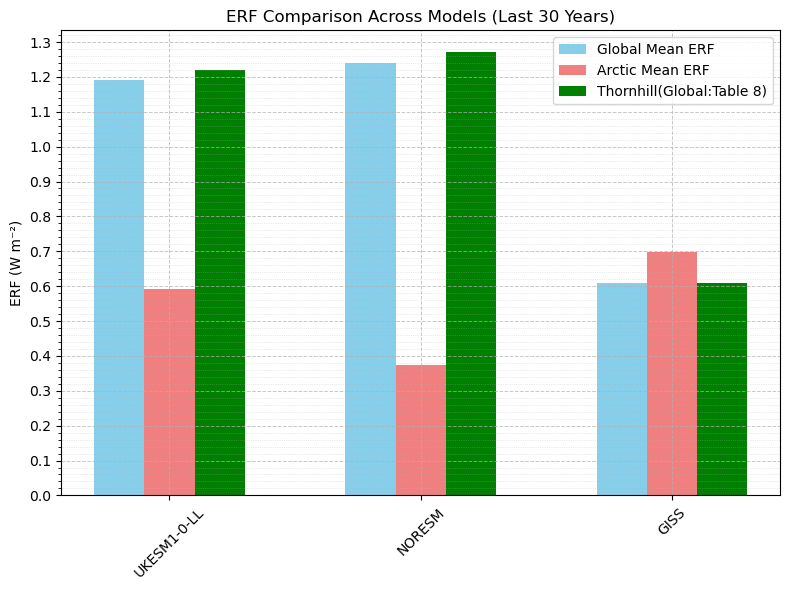

In [17]:
# Prepare data for plotting

models = ['UKESM1-0-LL', 'NORESM', 'GISS']
global_erfs = [abs(global_mean_ERF_last30.values), abs(global_mean_ERF1_last30.values), abs(global_mean_ERF2_last30.values)]
arctic_erfs = [abs(arctic_mean_ERF_UKESM.values), abs(arctic_mean_ERF_NORESM.values), abs(arctic_mean_ERF_GISS.values)]
Thornhill = [abs(-1.22), abs(-1.27), abs(-0.61)]
# Create bar plot
x = np.arange(len(models))  # Label locations
width = 0.20  # Width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width, global_erfs, width, label='Global Mean ERF', color='skyblue')
ax.bar(x, arctic_erfs, width, label='Arctic Mean ERF', color='lightcoral')
ax.bar(x + width, Thornhill, width, label='Thornhill(Global:Table 8)', color='green')

# Add precise grid
ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))  # Grid every 0.1 units
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.02))  # Minor ticks every 0.02 units
ax.grid(True, which='major', linestyle='-', linewidth=0.7, alpha=0.7)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax.set_ylabel('ERF (W m⁻²)')
ax.set_title('ERF Comparison Across Models (Last 30 Years)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

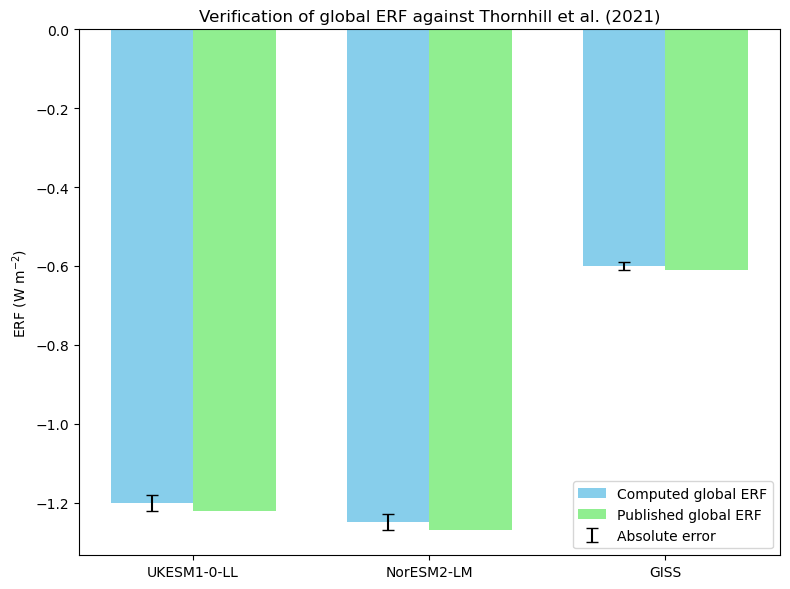

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# example arrays for computed and published ERF (W m^-2)
models = ['UKESM1-0-LL', 'NorESM2-LM', 'GISS']
computed_erf = np.array([-1.20, -1.25, -0.60])  # replace with actual values from analysis
published_erf = np.array([-1.22, -1.27, -0.61])  # Thornhill et al. Table 8 values

# calculate absolute and percentage errors
errors = computed_erf - published_erf
percentage_errors = errors / published_erf * 100

# create bar chart with error bars
x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x, computed_erf, width, label='Computed global ERF', color='skyblue')
ax.bar(x + width, published_erf, width, label='Published global ERF', color='lightgreen')
ax.errorbar(x, computed_erf, yerr=np.abs(errors), fmt='none', ecolor='black', capsize=4, label='Absolute error')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(models)
ax.set_ylabel('ERF (W m$^{-2}$)')
ax.set_title('Verification of global ERF against Thornhill et al. (2021)')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
print({errors:.4f})

SyntaxError: invalid decimal literal (254646490.py, line 1)

Why is GISS Arctic higher than Global????!

## Thornhill  Article :
+ The paper addresses multiple pathways for aerosol and chemical feedback in the Earth system model.
+ Considering the dynamic Methane effect on the climate system (in CMIP6 : lifetime and emission **constant**)
+ Constant global temperature and change in other variables proportional to it ---> simplicity.
+ Diagnose key coefficients—radiative efficiencies (φ) and sensitivities (γ)—that combine to form overall feedback parameters (α = φ × γ).

 ##  Theory:
+ radiation imbalance due to forces, feedback and temperature!
+ Overall feedback is related to the burden of aerosol,  radiative efficiency and sensitivity!
+ φᵢ (radiative efficiency): Indicates how strongly a unit change in burden or emission
  of a species (e.g., in Tg or Tg yr⁻¹) affects the Earth’s radiation balance (W m⁻² per unit).(how much a change in a greenhouse gas affects radiation, W m⁻² per unit change in burden)

+ γᵢ (sensitivity): Represents how the burden or emission changes with temperature (e.g., Tg K⁻¹ or Tg yr⁻¹ K⁻¹).(1 degree increase in temperature cause how much excessive burden )
+ Mass = 1 Tg = 10¹² g    for CO2=A cube with sides ≈ 796 m (bigger than the Burj Khalifa)
## Simulation : 
+ PI control composition at a level of 1850 and warmer situation 4x CO2
+ 121-150 30-year simulation for both temperature change and burden or emission change.
+ temperature is not based on ECS (equilibrium climate sensitivity) but consistent with burden change
+ AOD for sulfate and organic no ERF! For reactive gasses, both concentration-based and emission-based.is a measure of how much Earth's global surface temperature will eventually rise in response to a doubling of atmospheric CO₂ concentrations (from pre-industrial levels of ~280 ppm to 560 ppm) after the climate system has fully equilibrated (typically over centuries to millennia).
  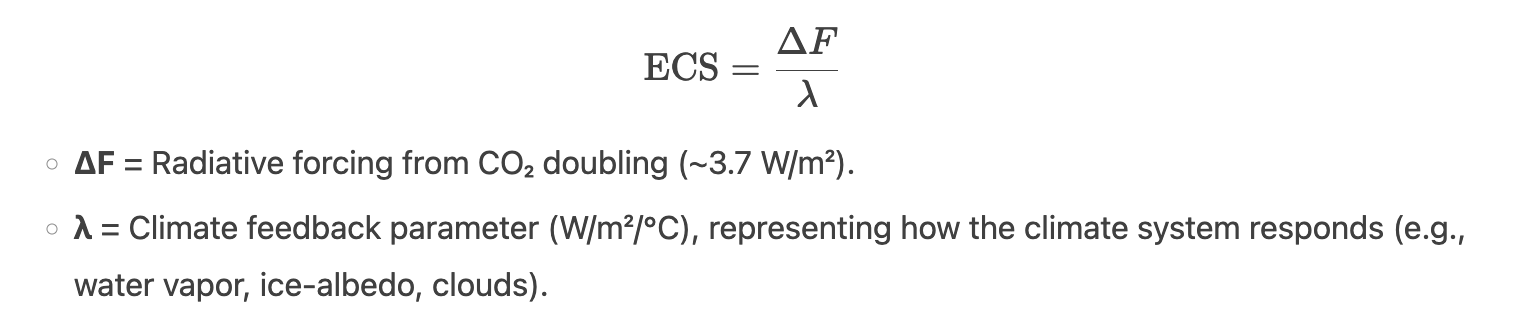
  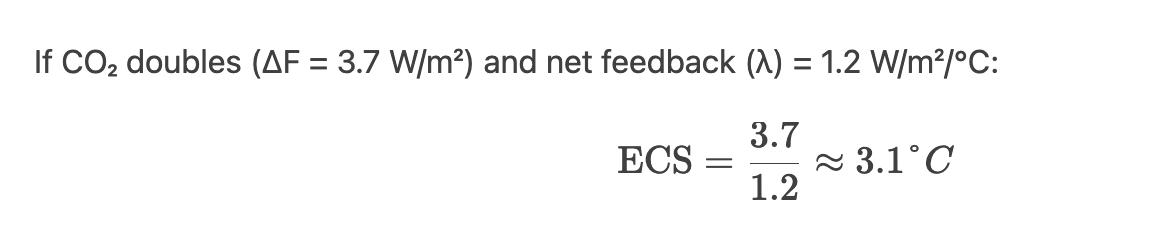
+ AerchMIP can't diagnose co2 cooling effect on stratosphere and vegetation!!

#### Table 1: Table 1:
Lists the “piClim” experiments in which natural emissions (dust, sea salt, DMS, NOx, BVOCs) are doubled relative to a 1850 control. This establishes the baseline for calculating radiative efficiencies (φ).

-end-

+ ozone effect(radiative forcing)! 3D OZONE DISTRIBUTION * 3D kernel of radiative efficiency! But increased from 10 % uncertainty to 15 % based on methane consideration.
+ Kernel is decomposing tools for small perturbation to cloud ice albedo vapor! But kernels will fail in large data.
## Model Description :
+ 7 Earth system model + ArchMIP+ ozon+ methane lifetime 
+ Bvocs: BVOCs are organic gases emitted by plants, fungi, and microorganisms as part of their natural metabolic processes. These compounds play a critical role in atmospheric chemistry, ecosystems, and even climate feedback.
Major Types:
Isoprene (C₅H₈): Most abundant (~50% of global BVOC emissions).
Monoterpenes (C₁₀H₁₆): E.g., α-pinene (smell of pine forests).
Sesquiterpenes (C₁₅H₂₄): Highly reactive.
Oxygenated VOCs: Methanol, acetone.
+ ### Land:
  Table 3 parametrized: wind speed, wind stress, bare soil , soil type,Bvocs emission, vegetation,photosynt,..
+ ### lightening:
  Nitrogen oxide 
+ ### Marin
  DMS sea salt